In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.6 MB/s eta 0:00:00


In [ ]:
from google.colab import files
import zipfile
import os

print("Upload the dataset:")
uploaded = files.upload()

# Automatically unzip it into the cloud server
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Extraction complete! Dataset is ready.")

Upload the dataset:


Saving dataset.zip to dataset.zip
Extraction complete! Dataset is ready.


In [ ]:
import yaml

colab_yaml = {
    'train': '/content/dataset/train/images',
    'val': '/content/dataset/test/images',
    'test': '/content/dataset/test/images',
    'nc': 3,
    'names': ['head', 'helmet', 'person']
}

with open('/content/dataset/data.yaml', 'w') as f:
    yaml.dump(colab_yaml, f)

print("data.yaml updated successfully")

data.yaml updated successfully


In [4]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data="/content/dataset/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

print("Training completed")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=6


image 1/1 c:\Users\ruchirpadhye\Downloads\Week 3-4\dataset\test\images\005298_jpg.rf.443bc565b6e0914f743da127c4cb0c0f.jpg: 640x640 8 helmets, 58.3ms
Speed: 3.8ms preprocess, 58.3ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\ruchirpadhye\Downloads\Week 3-4\runs\detect\predict-4


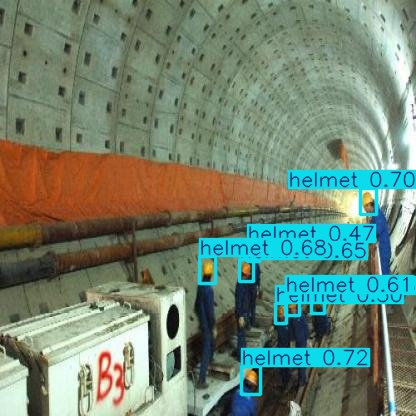

In [6]:
import os
import glob
from ultralytics import YOLO
from IPython.display import Image, display

model = YOLO('runs/detect/train/weights/best.pt')
test_images = glob.glob("dataset/test/images/*.jpg")

if test_images:
    test_img = test_images[0]
    
    # 3. Run prediction locally
    results = model.predict(source=test_img, conf=0.25, save=True)
    
    # 4. Display the result to confirm it works
    predict_runs = sorted(glob.glob('runs/detect/predict*'), key=os.path.getmtime)
    if predict_runs:
        latest_predict_dir = predict_runs[-1]
        result_img_path = os.path.join(latest_predict_dir, os.path.basename(test_img))
    
        display(Image(filename=result_img_path, width=800))
else:
    print("No local test images found to verify.")